# Machine Learning Project: Speech Emotion Recognition System - PART B (SYSTEMATIC IMPROVEMENTS)

In Part A (Baseline), we established a baseline using 162 standard acoustic features (MFCCs, mel spectrograms, chroma features, zero-crossing rate and RMS energy) with nine classical machine learning algorithms: Logistic Regression (LR), Support Vector Machine (SVM), K-Nearest Neighbors (KNN), Naive Bayes (NB), Gaussian Mixture Model (GMM), Decision Tree (DT), Bagging, Random Forest (RF),  AdaBoost.

In this notebook (Part B), we will sytematically improve upon this baseline through enhanced feature engineering (adding 48 features), advanced classification strategies (hierarchical classification & specialist classifiers for confused emotion pairs) and ensemble methods (stacking classifiers with optimized feature selection).

**COURSE:** 61.501 Production Ready ML – Sep 2025      

**TEAM:**  
Sagar Pratap Singh | 1010738  
Seow Chun Yong | 1000108  
Yang Qingwei | 1010737

**REQUIREMENTS:**  
numpy==2.3.5  
scipy==1.16.3  
pandas==2.3.3  
scikit-learn==1.7.2  
matplotlib==3.10.7  
seaborn==0.13.2  
librosa==0.11.0  
jupyterlab==4.5.0  

**INSTRUCTIONS TO RETRAIN THE MODELS IN ITS ENTIRETY (TAKES 3-4HRS TO RUN)**  
**NOTE:** Due to the number of experiments that you have to run, **each** notebook will take 3-4 hours to run.

1. git clone https://github.com/sagerstack/ml-speech-emotion-recognition.git
2. Download CREMA-D Dataset:
    - Navigate to https://drive.google.com/drive/folders/1tvWeyxZM0bvKVhogRD1yCnwnpgOScJet?usp=share_link
    - Download `AudioWAV` folder in its entirety, and place the folder in `notebooks\AudioWAV`.
    - Alternatively, you may download CREMA-D Dataset from : https://www.kaggle.com/datasets/ejlok1/cremad 
    - Ensure you unzip the audio files into `notebooks\AudioWAV` directory.
3. Install required python packages: `pip install -r requirements.txt`  
4. Open `PART A - Baseline Models.ipynb` or `PART B - Systematic Improvements.ipynb` in Jupyter Notebook.  
5. Run all cells in order (Kernel → Restart & Run All).  
6. Training results and plots will be displayed at the end.

## Import Libraries

In [17]:
# Standard library
import os

# Data handling
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Audio utilities
import librosa

# Scikit-learn: preprocessing, model selection, metrics, feature selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 42

## Feature Engineering & Extraction

**Base features from PART A (Baseline)**
1. **Zero Crossing Rate**: The rate of sign-changes of the signal during the duration of a particular frame.
2. **Chroma Vector**: A 12-element representation of the spectral energy where the bins represent the 12 equal-tempered pitch classes of western-type music (semitone spacing).
3. **MFCC**: Mel Frequency Cepstral Coefficients form a cepstral representation where the frequency bands are not linear but distributed according to the mel-scale.
4. **Root Mean Square Energy (RMS)**: A measure of the signal's loudness/energy, computed as the square root of the mean of squared amplitude values.
5. **Mel Spectrogram**: A representation of how energy is distributed across different frequencies over time, scaled to match human hearing perception.

**Enhanced features from PART B (Systematic Improvements)**
1. **Delta MFCCs**: Delta features capture the rate of change of MFCCs over time. It tells us how the voice is changing.  
2. **Delta-Delta MFCCs**: The derivative of Delta. It captures the acceleration of change.   
3. **Prosodic**: Prosody refers to the "melody" of speech – the patterns of pitch, rhythm and stress that convey meaning beyond words.   

**Data Augmentation**  
To increase training data diversity and improve model robustness to real-world variations, we apply augmentation to grow the dataset. Each original clip is kept, plus two augmented variants, giving a 3x expansion:  
•	Variant 1 (Random Noise): Add random noise to simulate mic/background variability and misalignment.  
•	Variant 2 (Stretch/Pitch Shift): Shift pitch slightly to simulate more realistic speaker pitch variation.

In [18]:
def extract_features_enhanced(data, sr):
    """
    Extract 210 features:
    - Original 162 features
    - Delta MFCCs (20)
    - Delta-Delta MFCCs (20)
    - Prosodic features (8)
    """
    # data, sr = librosa.load(path, duration=2.5, offset=0.6)
    # data, index = librosa.effects.trim(data, top_db=20)
    result = np.array([])
    
    # === ORIGINAL FEATURES (162) ===
    # ZCR (1)
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result = np.hstack((result, zcr))
    
    # Chroma STFT (12)
    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T, axis=0)
    result = np.hstack((result, chroma_stft))
    
    # MFCC (20)
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=20)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    result = np.hstack((result, mfcc_mean))
    
    # RMS (1)
    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms))
    
    # Mel Spectrogram (128)
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sr).T, axis=0)
    result = np.hstack((result, mel))
    
    # === NEW: DELTA FEATURES (40) ===
    # Delta MFCC (20) - first derivative
    delta_mfcc = librosa.feature.delta(mfcc)
    delta_mfcc_mean = np.mean(delta_mfcc.T, axis=0)
    result = np.hstack((result, delta_mfcc_mean))
    
    # Delta-Delta MFCC (20) - second derivative
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)
    delta2_mfcc_mean = np.mean(delta2_mfcc.T, axis=0)
    result = np.hstack((result, delta2_mfcc_mean))
    
    # === NEW: PROSODIC FEATURES (8) ===
    # Pitch statistics (5)
    pitches, magnitudes = librosa.piptrack(y=data, sr=sr)
    pitch_values = pitches[pitches > 0]
    
    if len(pitch_values) > 0:
        pitch_mean = np.mean(pitch_values)
        pitch_std = np.std(pitch_values)
        pitch_max = np.max(pitch_values)
        pitch_min = np.min(pitch_values)
        pitch_range = pitch_max - pitch_min
    else:
        pitch_mean = pitch_std = pitch_max = pitch_min = pitch_range = 0
    
    # Energy dynamics (3)
    rms_full = librosa.feature.rms(y=data)[0]
    energy_std = np.std(rms_full)
    energy_slope = np.polyfit(range(len(rms_full)), rms_full, 1)[0] if len(rms_full) > 1 else 0
    energy_range = np.max(rms_full) - np.min(rms_full) if len(rms_full) > 0 else 0
    
    prosodic = np.array([pitch_mean, pitch_std, pitch_range, pitch_max, pitch_min,
                         energy_std, energy_slope, energy_range])
    result = np.hstack((result, prosodic))
    
    return result

def noise_snr(data, snr_db=20):
    signal_power = np.mean(data ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), len(data))
    return data + noise

def pitch(data, sr, pitch_factor=0.7):
    try:
        return librosa.effects.pitch_shift(data, sr=sr, n_steps=pitch_factor)
    except TypeError:
        try:
            return librosa.effects.pitch_shift(y=data, sr=sr, n_steps=pitch_factor)
        except:
            return data

### CREMA-D
#### Crowd Sourced Emotional Multimodal Actors Dataset
CREMA-D is a data set of 7,442 original clips from 91 actors. These clips were from 48 male and 43 female actors between the ages of 20 and 74 coming from a variety of races and ethnicities (African America, Asian, Caucasian, Hispanic, and Unspecified). Actors spoke from a selection of 12 sentences. The sentences were presented using one of six different emotions (Anger, Disgust, Fear, Happy, Neutral, and Sad) and four different emotion levels (Low, Medium, High, and Unspecified).

https://www.kaggle.com/datasets/ejlok1/cremad

In [19]:
Crema = "./AudioWAV/"
crema_directory_list = os.listdir(Crema)

file_emotion = []
file_path = []

for file in crema_directory_list:
    if not file.lower().endswith('.wav'):
        continue
    # storing file paths
    file_path.append(Crema + file)
    # storing file emotions
    part=file.split('_')
    if part[2] == 'SAD':
        file_emotion.append('sad')
    elif part[2] == 'ANG':
        file_emotion.append('angry')
    elif part[2] == 'DIS':
        file_emotion.append('disgust')
    elif part[2] == 'FEA':
        file_emotion.append('fear')
    elif part[2] == 'HAP':
        file_emotion.append('happy')
    elif part[2] == 'NEU':
        file_emotion.append('neutral')
    else:
        file_emotion.append('Unknown')
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotion'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Crema_df = pd.concat([emotion_df, path_df], axis=1)
Crema_df = Crema_df[Crema_df['Emotion'] != 'Unknown']
demographics_df = pd.read_csv("VideoDemographics.csv")
actor_genders = []
Crema_df["ActorID"] = Crema_df["Path"].str.extract(pat=r'/(\d{4})_.+\.wav').astype(int)
Crema_df = pd.merge(Crema_df, demographics_df, on="ActorID", how="left")
Crema_df.sample(5)

,Emotion,Path,ActorID,Age,Sex,Race,Ethnicity
6634,sad,./AudioWAV/1015_ITS_SAD_XX.wav,1015,32,Male,African American,Not Hispanic
3593,sad,./AudioWAV/1035_DFA_SAD_XX.wav,1035,48,Male,Caucasian,Not Hispanic
4450,angry,./AudioWAV/1020_IWW_ANG_XX.wav,1020,61,Female,Caucasian,Not Hispanic
6656,neutral,./AudioWAV/1083_IWL_NEU_XX.wav,1083,45,Male,African American,Not Hispanic
2318,fear,./AudioWAV/1073_IWL_FEA_XX.wav,1073,24,Female,African American,Hispanic


In [ ]:
X = np.array([])
y = np.array([])

rng = np.random.default_rng()
for idx, row in Crema_df.iterrows():
    path = row['Path']
    label = row['Emotion']
    # 1. Load the audio file and trim away the silence at the start and end of each file
    data, sr = librosa.load(path, duration=2.5, offset=0.6)
    data, dummy = librosa.effects.trim(data, top_db=20)
    # 2. Create synthetic data with random noise
    snr_db = rng.uniform(low=20, high=50)
    data_noise = noise_snr(data, snr_db=snr_db)
    # 3. Create synthetic data with random pitch shift
    pitch_factor = rng.uniform(low=0.5, high=1.5)
    data_pitch = pitch(data, sr, pitch_factor=pitch_factor)
    # 4. Extract features from:
    #    (1) original audio
    #    (2) original audio + random noise
    #    (3) original audio + random pitch shift
    try:
        X = np.vstack((X, [extract_features_enhanced(data, sr),
                          extract_features_enhanced(data_noise, sr),
                          extract_features_enhanced(data_pitch, sr)]))
    except ValueError:
        X = np.array([extract_features_enhanced(data, sr),
                    extract_features_enhanced(data_noise, sr),
                    extract_features_enhanced(data_pitch, sr)])
    y = np.hstack((y, [label]*3))
    # Print progress bar
    if idx % 500 == 0:
        print('.', end='')
# Save features as csv
np.savetxt('features_crema_with_aug.csv', X, delimiter=',', fmt='%f')
# Save labels as csv
np.savetxt('labels_crema_with_aug.csv', y, delimiter=',', fmt='%s')

In [20]:
# Load features from csv
X = pd.read_csv('features_crema_with_aug.csv', header=None).values
# Load labels from csv
y = np.ravel(pd.read_csv('labels_crema_with_aug.csv', header=None).values)
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE)

## Model Selection and Hyperparameter Tuning

### RandomizedSearchCV for hyperparameter tuning of base classifiers

In [21]:
def RandomizedSearchCV_wrapper(estimator, param_dist, X_train, X_test, y_train, y_test):
    random_search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=10, # Number of iterations/samples to try
        cv=5, # 5-fold cross-validation
        verbose=1, # Prints progress
        random_state=42,
        n_jobs=-1, # Use all available cores
        return_train_score=True,
    )
    
    # Fit the RandomizedSearchCV to the training data
    random_search.fit(X_train, y_train)
    
    # Print the best parameters and score
    print(f"Best parameters found: {random_search.best_params_}")
    print(f"Best cross-validation score: {random_search.best_score_:.4f}")
    
    # Evaluate on the test set
    best_model = random_search.best_estimator_
    test_score = best_model.score(X_test, y_test)
    print(f"Test set accuracy of the best model: {test_score:.4f}")
    return best_model, random_search.cv_results_

As we are using several models in an ensemble, we want to ensure that all features are scaled appropriately. 

This will be added to each model pipeline after hyperparameter tuning is completed.

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# guard against any NaN/Inf values that can destabilize solvers; map inf -> 0
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0, copy=False)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0, copy=False)

# clip extreme values to avoid overflow in linear solvers
X_train_scaled = np.clip(X_train_scaled, -10, 10, out=X_train_scaled)
X_test_scaled = np.clip(X_test_scaled, -10, 10, out=X_test_scaled)

# enforce float64 for numerical stability
X_train_scaled = X_train_scaled.astype('float64', copy=False)
X_test_scaled = X_test_scaled.astype('float64', copy=False)



In [23]:
from scipy.stats import reciprocal, uniform, randint, loguniform
import pickle
import json

class NumpyArrayEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, np.int64):
            return int(obj)
        return json.JSONEncoder.default(self, obj)

#### Support Vector Machine

In [24]:
svm_param_dist = {
    'C': reciprocal(0.1, 1000),  # Regularization parameter. Use reciprocal for a wide range.
    'kernel': ['poly', 'rbf', 'sigmoid'], # Kernel type. Discrete choices.
    'gamma': reciprocal(0.001, 10), # Kernel coefficient for 'rbf', 'poly', 'sigmoid'.
                                   # Use reciprocal for a wide range, or 'scale' or 'auto'.
    'degree': [2, 3, 4],           # Degree of the polynomial kernel function ('poly').
    'coef0': uniform(-1, 2)        # Independent term in kernel function ('poly', 'sigmoid').
}
best_svm, svm_cv_results = RandomizedSearchCV_wrapper(SVC(), svm_param_dist, X_train_scaled, X_test_scaled, y_train, y_test)

pickle_filename = 'best_svm.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(best_svm, f)
with open('svm_cv_results.json', 'w') as f:
    json.dump(svm_cv_results, f, cls=NumpyArrayEncoder, indent=4)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found: {'C': np.float64(54.08216580718487), 'coef0': np.float64(0.21999331556524182), 'degree': 4, 'gamma': np.float64(0.004936948694960458), 'kernel': 'poly'}
Best cross-validation score: 0.6535
Test set accuracy of the best model: 0.7094


In [25]:
print(f"Mean Train Scores: {svm_cv_results['mean_train_score']}")
print(f"Mean Test Scores: {svm_cv_results['mean_test_score']}")

Mean Train Scores: [0.99988055 0.28139924 0.73220259 0.99979097 0.26446773 0.29328415
 0.50536026 0.99988055 0.4304525  0.90368196]
Mean Test Scores: [0.62935927 0.1323459  0.60421678 0.26940994 0.27078304 0.30488478
 0.47276515 0.20007176 0.39870999 0.65354761]


#### RandomForestClassifier

In [26]:
rf_param_dist = {
    'n_estimators': randint(low=50, high=500),  # Number of trees in the forest
    'max_features': ['sqrt', 'log2', None],  # Number of features to consider when looking for the best split
    'max_depth': randint(low=5, high=30),  # Maximum depth of the tree
    'min_samples_split': randint(low=2, high=20),  # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(low=1, high=10),  # Minimum number of samples required to be at a leaf node
    'bootstrap': [True, False],  # Whether bootstrap samples are used when building trees
    'criterion': ['gini', 'entropy']  # Function to measure the quality of a split
}
best_rf, rf_cv_results = RandomizedSearchCV_wrapper(RandomForestClassifier(), rf_param_dist, X_train_scaled, X_test_scaled, y_train, y_test)

pickle_filename = 'best_rf.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(best_rf, f)
with open('rf_cv_results.json', 'w') as f:
    json.dump(rf_cv_results, f, cls=NumpyArrayEncoder, indent=4)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found: {'bootstrap': False, 'criterion': 'gini', 'max_depth': 26, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 13, 'n_estimators': 463}
Best cross-validation score: 0.6736
Test set accuracy of the best model: 0.7365


In [27]:
print(f"Mean Train Scores: {rf_cv_results['mean_train_score']}")
print(f"Mean Test Scores: {rf_cv_results['mean_test_score']}")

Mean Train Scores: [0.96216555 0.92149429 0.99874582 0.99622253 0.94932517 0.8792105
 0.98944399 0.97726054 0.92309188 0.80972289]
Mean Test Scores: [0.61747486 0.60469423 0.67361434 0.65981866 0.61843062 0.47658785
 0.64202064 0.63025549 0.59233192 0.54102935]


#### Gaussian Naive-Bayes

In [28]:
nb_param_dist = {'var_smoothing': loguniform(1e-9, 1e-1)}
best_nb, nb_cv_results = RandomizedSearchCV_wrapper(GaussianNB(), nb_param_dist, X_train_scaled, X_test_scaled, y_train, y_test)

pickle_filename = 'best_nb.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(best_nb, f)
with open('nb_cv_results.json', 'w') as f:
    json.dump(nb_cv_results, f, cls=NumpyArrayEncoder, indent=4)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found: {'var_smoothing': np.float64(0.04033800832600378)}
Best cross-validation score: 0.3192
Test set accuracy of the best model: 0.3303


In [29]:
print(f"Mean Train Scores: {nb_cv_results['mean_train_score']}")
print(f"Mean Test Scores: {nb_cv_results['mean_test_score']}")

Mean Train Scores: [0.25583796 0.32014452 0.27257556 0.25559907 0.25586782 0.25586782
 0.25586782 0.32144343 0.25562893 0.26543858]
Mean Test Scores: [0.2537031  0.31921888 0.26988677 0.25358364 0.2537031  0.2537031
 0.2537031  0.31748699 0.25358364 0.26289964]


#### ExtraTreesClassifier

In [30]:
et_param_dist = {
    'n_estimators': randint(low=10, high=200),
    'max_depth': [None] + list(randint(3, 20).rvs(10)), # Sample integer values for max_depth or allow 'None'
    'min_samples_split': randint(low=2, high=20),
    'min_samples_leaf': randint(low=1, high=20),
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy'], # ExtraTreesClassifier supports 'gini', 'entropy', 'log_loss'
    'max_features': ['sqrt', 'log2', None] + list(uniform(0.1, 0.9).rvs(10)) # Sample from a distribution or choose from a list
}
best_et, et_cv_results = RandomizedSearchCV_wrapper(ExtraTreesClassifier(), et_param_dist, X_train_scaled, X_test_scaled, y_train, y_test)

pickle_filename = 'best_et.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(best_et, f)
with open('et_cv_results.json', 'w') as f:
    json.dump(et_cv_results, f, cls=NumpyArrayEncoder, indent=4)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': np.int64(17), 'max_features': np.float64(0.9980712145201469), 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 60}
Best cross-validation score: 0.6717
Test set accuracy of the best model: 0.7302


In [31]:
print(f"Mean Train Scores: {et_cv_results['mean_train_score']}")
print(f"Mean Test Scores: {et_cv_results['mean_test_score']}")

Mean Train Scores: [0.79853974 0.99166865 0.59728867 0.66361094 0.99976111 0.65100932
 0.81871116 0.93051243 0.42424181 0.75182145]
Mean Test Scores: [0.53684957 0.62631378 0.45090742 0.47927577 0.67170319 0.50477785
 0.52526302 0.58886772 0.39745549 0.51086945]


#### GradientBoostingClassifier

In [33]:
gb_param_dist = {
    'n_estimators': randint(100, 1000),      # Sample integers between 100 and 1000
    'learning_rate': uniform(0.01, 0.2),     # Sample floats between 0.01 and 0.2
    'max_depth': randint(3, 10),             # Sample integers between 3 and 10
    'min_samples_split': randint(2, 20),     # Sample integers between 2 and 20
    'min_samples_leaf': randint(1, 20),      # Sample integers between 1 and 20
    'max_features': ['sqrt', 'log2', None]   # Sample from a discrete list
}
best_gb, gb_cv_results = RandomizedSearchCV_wrapper(GradientBoostingClassifier(), gb_param_dist, X_train_scaled, X_test_scaled, y_train, y_test)

pickle_filename = 'best_gb.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(best_gb, f)
with open('gb_cv_results.json', 'w') as f:
    json.dump(gb_cv_results, f, cls=NumpyArrayEncoder, indent=4)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found: {'learning_rate': np.float64(0.0849080237694725), 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 11, 'min_samples_split': 9, 'n_estimators': 800}
Best cross-validation score: 0.7283
Test set accuracy of the best model: 0.7874


In [34]:
print(f"Mean Train Scores: {gb_cv_results['mean_train_score']}")
print(f"Mean Test Scores: {gb_cv_results['mean_test_score']}")

Mean Train Scores: [0.99988055 0.96004543 0.99965659 0.99977604 0.99988055 0.99988055
 0.82575848 0.99988055 0.77032066 0.99988055]
Mean Test Scores: [0.72826099 0.63186827 0.68418544 0.68962033 0.71960135 0.72312488
 0.57973046 0.69828032 0.56503841 0.71315097]


Upon inspecting the cross validation results, it appears that the best parameter set takes more than 4 hours to train, and the 2nd best parameter set takes 3 minutes while sacrificing only a marginal amount of accuracy. We therefore save and use the 2nd best parameter set to be part of the final ensemble model. 

In [35]:
second_best_gb_params = {
    "learning_rate": 0.20475110376829186,
    "max_depth": 9,
    "max_features": "log2",
    "min_samples_leaf": 15,
    "min_samples_split": 13,
    "n_estimators": 666
}
second_best_gb = GradientBoostingClassifier(**second_best_gb_params)
pickle_filename = 'second_best_gb.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(second_best_gb, f)


#### K Nearest Neighbors

In [36]:
knn_param_dist = {
    'n_neighbors': randint(1, 21),  # Explore k from 1 to 20
    'weights': ['uniform', 'distance'], # Explore uniform and distance weighting
    'metric': ['euclidean', 'manhattan', 'minkowski'], # Common distance metrics
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'] # Algorithm for neighbor search
}
best_knn, knn_cv_results = RandomizedSearchCV_wrapper(KNeighborsClassifier(), knn_param_dist, X_train_scaled, X_test_scaled, y_train, y_test)

pickle_filename = 'best_knn.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(best_knn, f)
with open('knn_cv_results.json', 'w') as f:
    json.dump(knn_cv_results, f, cls=NumpyArrayEncoder, indent=4)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found: {'algorithm': 'brute', 'metric': 'minkowski', 'n_neighbors': 2, 'weights': 'distance'}
Best cross-validation score: 0.6599
Test set accuracy of the best model: 0.7202


In [37]:
print(f"Mean Train Scores: {knn_cv_results['mean_train_score']}")
print(f"Mean Test Scores: {knn_cv_results['mean_test_score']}")

Mean Train Scores: [0.55721448 0.99988055 0.59521321 0.99988055 0.99988055 0.99988055
 0.99988055 0.60548559 0.99988055 0.99988055]
Mean Test Scores: [0.45598399 0.56724804 0.46261301 0.59878148 0.65987834 0.61884817
 0.65987834 0.47700628 0.5434183  0.52514355]


#### LogisticRegression

In [ ]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=Warning,
    module=r"sklearn\\linear_model"    
)

lr_param_dist = [
    # Use 'saga' for all penalties including elasticnet and none
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2', 'elasticnet', None],
        'C': loguniform(1e-4, 1e4),
        'l1_ratio': uniform(0, 1)
    },
    # Use 'liblinear' for l1/l2 (no elasticnet/none)
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': loguniform(1e-4, 1e4),
        'l1_ratio': [None] # l1_ratio is ignored by liblinear
    },
    # Use 'lbfgs', 'newton-cg', 'sag', 'newton-cholesky' for l2 or none
    {
        'solver': ['lbfgs', 'newton-cg', 'sag', 'newton-cholesky'],
        'penalty': ['l2', None],
        'C': loguniform(1e-4, 1e4),
        'l1_ratio': [None] # l1_ratio is ignored
    }
]
best_lr, lr_cv_results = RandomizedSearchCV_wrapper(LogisticRegression(), lr_param_dist, X_train_scaled, X_test_scaled, y_train, y_test)

pickle_filename = 'best_lr.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(best_lr, f)
with open('lr_cv_results.json', 'w') as f:
    json.dump(lr_cv_results, f, cls=NumpyArrayEncoder, indent=4)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found: {'C': np.float64(0.47205340620449887), 'l1_ratio': None, 'penalty': 'l2', 'solver': 'newton-cholesky'}
Best cross-validation score: 0.4829
Test set accuracy of the best model: 0.4998


In [ ]:
print(f"Mean Train Scores: {lr_cv_results['mean_train_score']}")
print(f"Mean Test Scores: {lr_cv_results['mean_test_score']}")

Mean Train Scores: [0.50948098 0.50707715 0.51267615 0.51618486 0.48390468 0.50712194
 0.50053749 0.51233274 0.51618486 0.17359951]
Mean Test Scores: [0.48064939 0.47957441 0.48285938 0.48160504 0.46768939 0.47945493
 0.480052   0.48279959 0.48160504 0.17361437]


## Assembling the Model Pipelines

In [11]:
# Load optimized models so we don't have to keep retraining the models from scratch

import pickle

with open('best_svm.pkl', 'rb') as f:
    best_svm = pickle.load(f)
with open('best_rf.pkl', 'rb') as f:
    best_rf = pickle.load(f)
with open('best_nb.pkl', 'rb') as f:
    best_nb = pickle.load(f)
with open('best_et.pkl', 'rb') as f:
    best_et = pickle.load(f)
with open('second_best_gb.pkl', 'rb') as f:
    second_best_gb = pickle.load(f)
    second_best_gb.fit(X_train_scaled, y_train)
with open('best_knn.pkl', 'rb') as f:
    best_knn = pickle.load(f)
with open('best_lr.pkl', 'rb') as f:
    best_lr = pickle.load(f)    


# Confusion Matrix for Enhanced Base Models
In Part A (baseline), models were trained using a baseline set of 162 features, including MFCCs, Chroma, ZCR, RMS, and Mel Spectrograms. These are good for capturing the static acoustic properties of the audio.

In Part B (this notebook), we have expanded this to 210 features by adding:
1) Delta & Delta-Delta MFCCs (40 new features): These capture the temporal dynamics of the speech—not just the sound at a moment, but how it's changing. This is crucial for distinguishing emotions, as the intonation and contour of speech are highly expressive.
2) Prosodic Features (8 new features): These directly measure the "melody" of speech, such as pitch statistics and energy dynamics, which are very strong emotional indicators.
3) Smarter Data Augmentation: While both notebooks use data augmentation to triple the dataset size, Part B's implementation is slightly more robust. It uses randomized values for the noise level and pitch-shifting factor for each audio file, creating a more diverse and varied training set compared to a potentially fixed augmentation in Part A (baseline).
4) Enhanced Hyperparameter Tuning: Part A tunes the models with a small grid: C ∈ {1, 10, 50}, gamma ∈ {‘scale’, ‘auto’}. Part B uses RandomizedSearchCV_wrapper with a much wider distribution over C and gamma, and multiple kernels (rbf, poly, sigmoid). This lets the search find a much better‑fitting model for the new feature space.

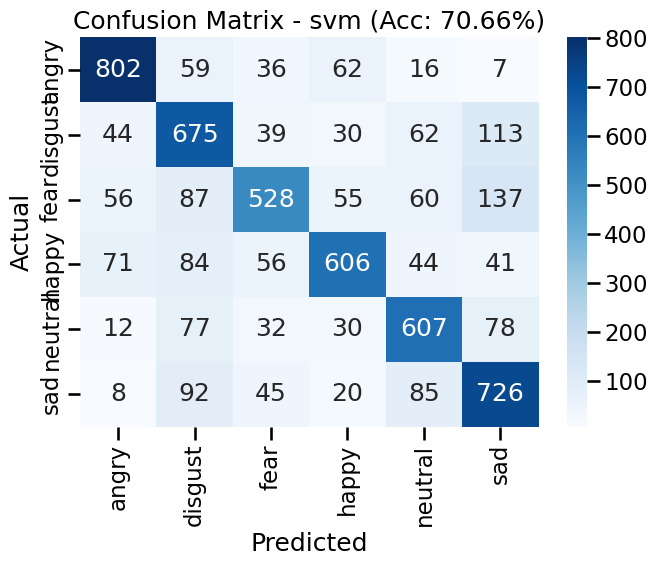

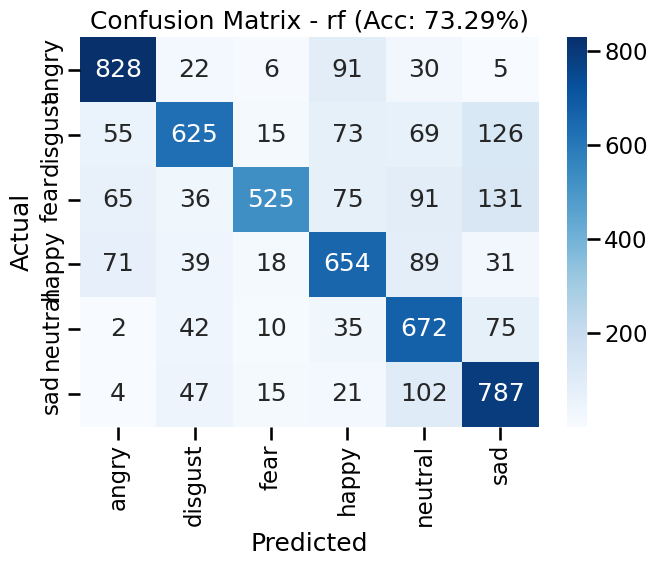

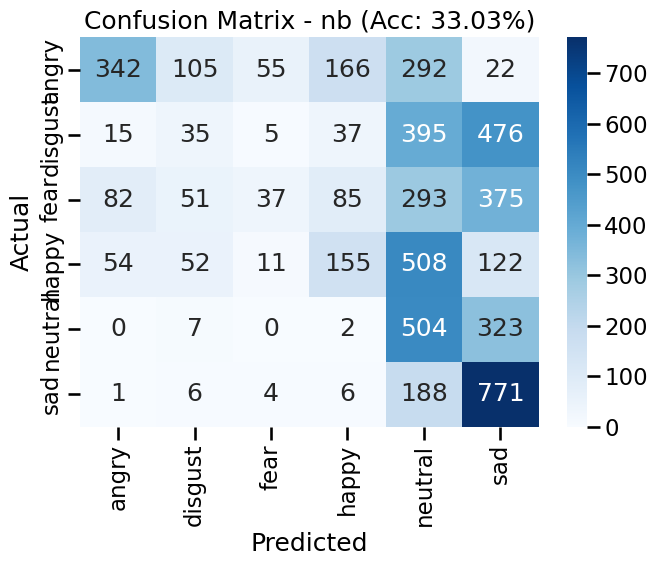

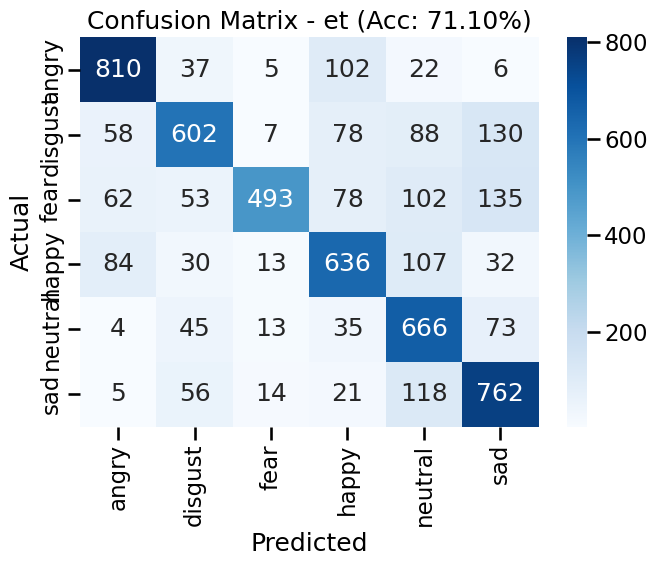

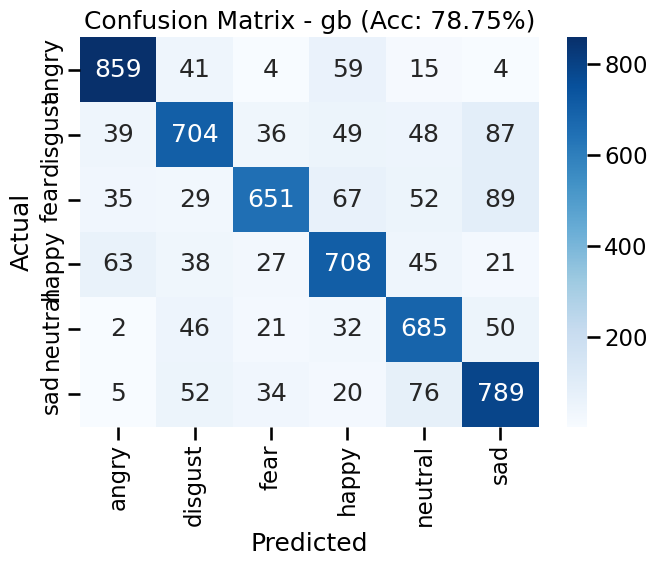

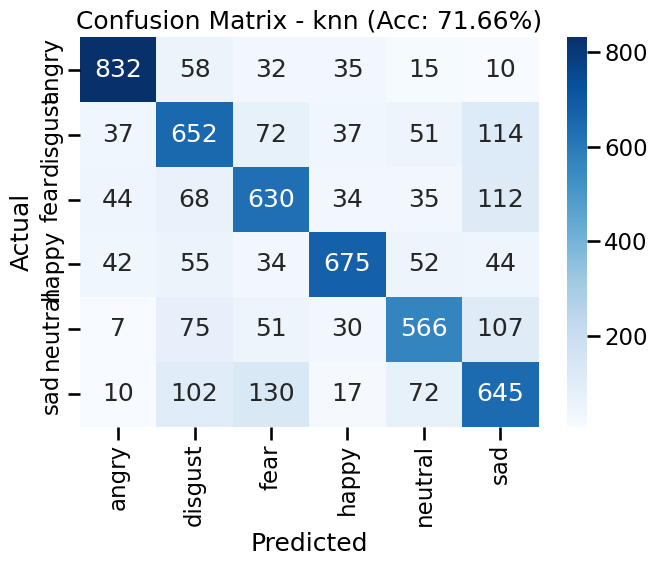

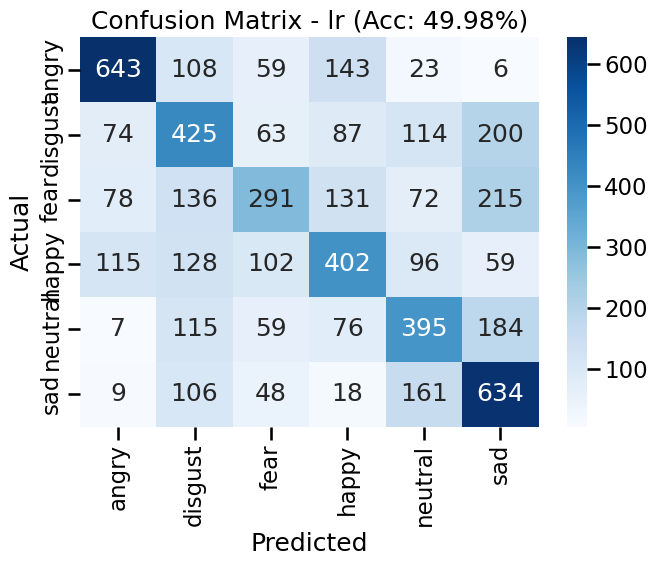

,model,accuracy
4,gb,0.787531
1,rf,0.732891
5,knn,0.716589
3,et,0.711035
0,svm,0.706557
6,lr,0.499821
2,nb,0.330348


In [12]:
# Confusion matrices for tuned base models (enhanced features)
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

base_models = {
    'svm': best_svm,
    'rf': best_rf,
    'nb': best_nb,
    'et': best_et,
    'gb': second_best_gb,
    'knn': best_knn,
    'lr': best_lr,
}

sns.set_context('talk')
confusion_rows = []
for name, model in base_models.items():
    # All base models were tuned on X_train_scaled, so evaluate on the corresponding scaled test set
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    confusion_rows.append({'model': name, 'accuracy': acc})

    cm = confusion_matrix(y_test, y_pred)
    labels = sorted(list(set(y_test)))
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name} (Acc: {acc*100:.2f}%)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

confusion_df = pd.DataFrame(confusion_rows).sort_values('accuracy', ascending=False)
display(confusion_df)


# Experiment different ensemble models to find the Best Model
In this section, we explore whether combining the models into an ensemble can improve overall performance.

1) Using StackingClassifier, start with GradientBoosting because it's the best performing base model + the next best model. 
2) Plot the confusion matrix, f1 scores.
3) Add the next best model and plot the confusion matrix, f1 scores.
4) Keep doing it until all models are part of the ensemble.

Progressive stacking order: ['gb', 'rf', 'knn', 'et', 'svm', 'lr', 'nb']
Training stacking ensemble with models: ['gb', 'rf']


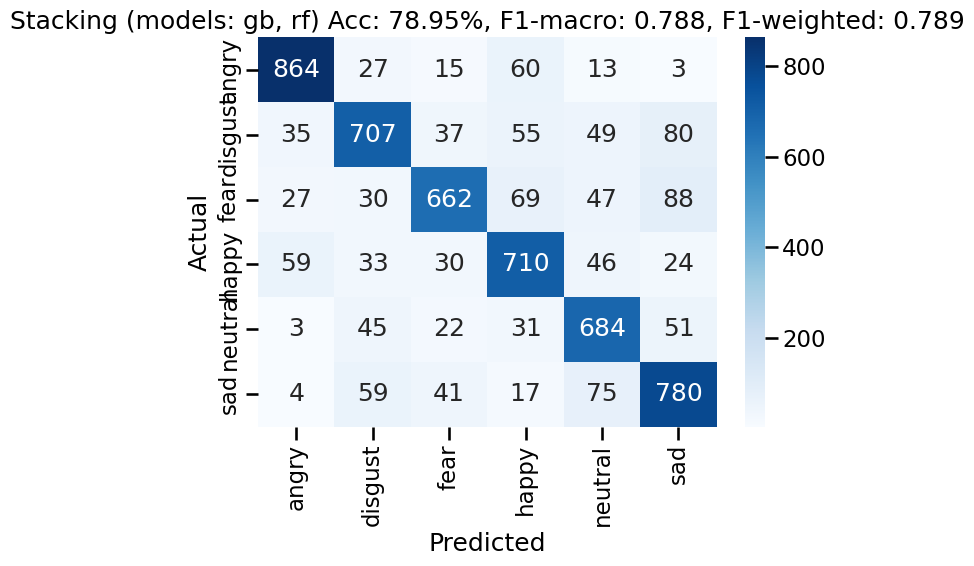

Training stacking ensemble with models: ['gb', 'rf', 'knn']


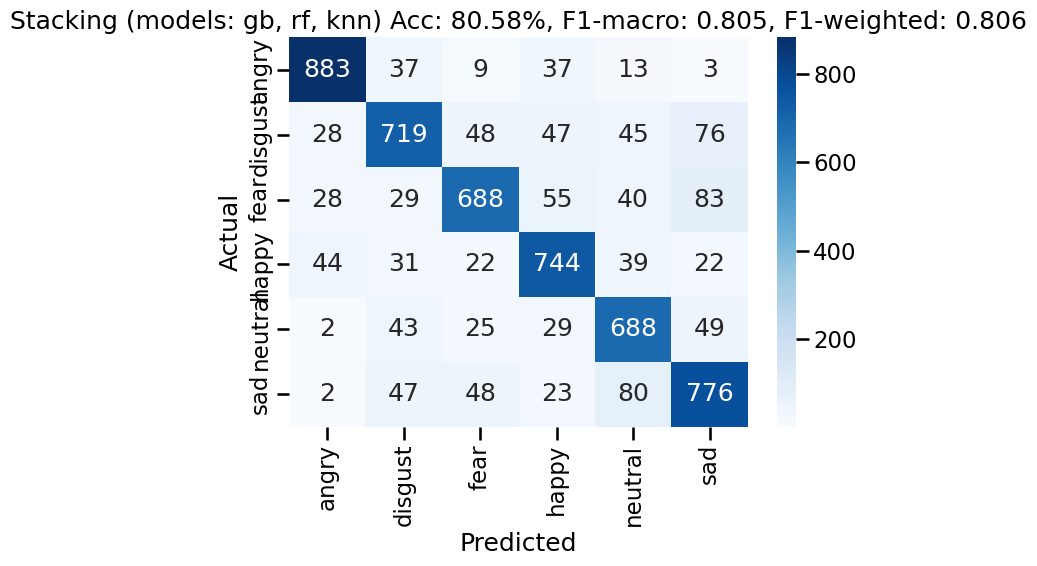

Training stacking ensemble with models: ['gb', 'rf', 'knn', 'et']


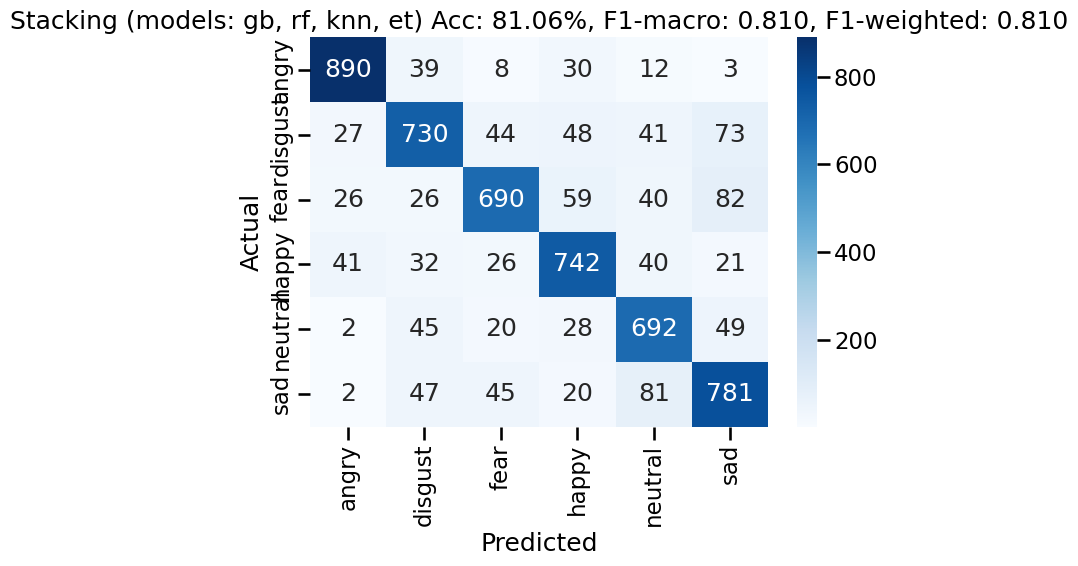

Training stacking ensemble with models: ['gb', 'rf', 'knn', 'et', 'svm']


/Users/yangqingwei/Library/CloudStorage/GoogleDrive-yangqingwei@gmail.com/My Drive/SUTD/Term 1/ML/ML Lab/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


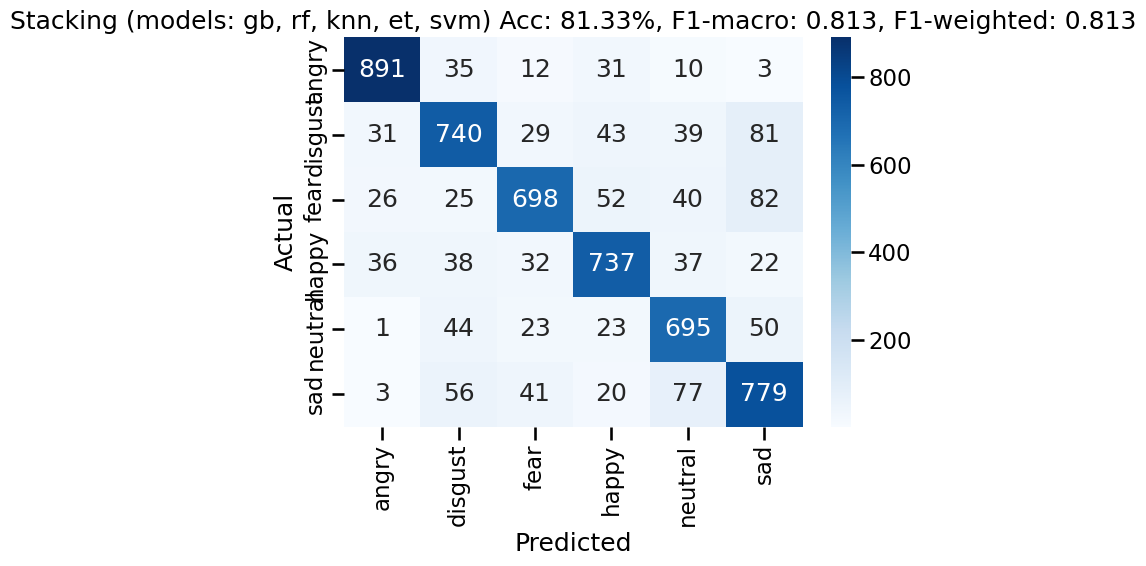

Training stacking ensemble with models: ['gb', 'rf', 'knn', 'et', 'svm', 'lr']


/Users/yangqingwei/Library/CloudStorage/GoogleDrive-yangqingwei@gmail.com/My Drive/SUTD/Term 1/ML/ML Lab/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


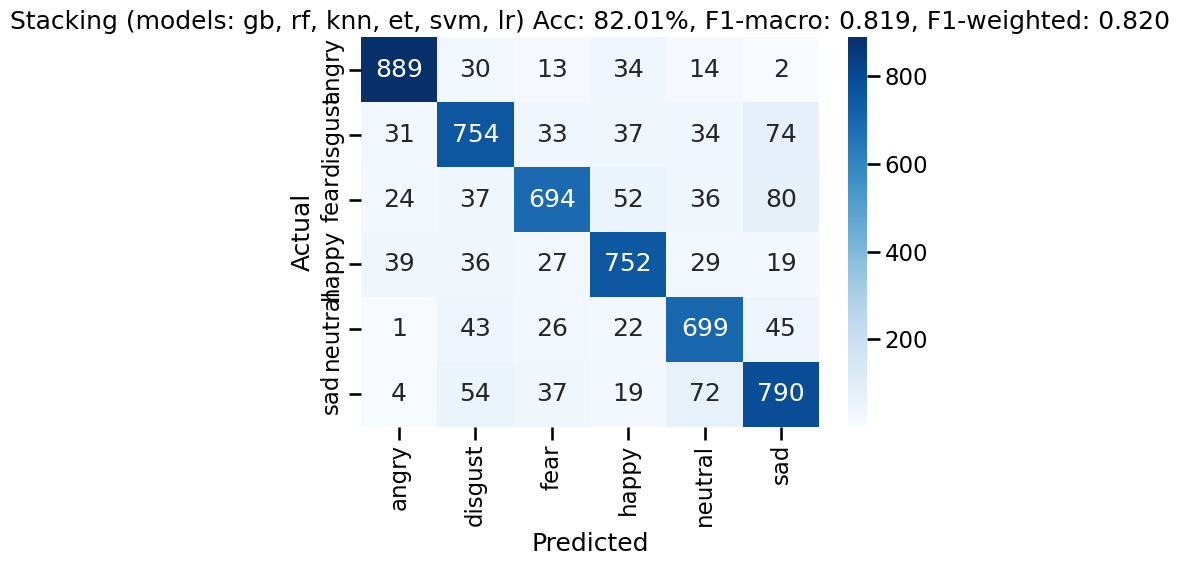

Training stacking ensemble with models: ['gb', 'rf', 'knn', 'et', 'svm', 'lr', 'nb']


/Users/yangqingwei/Library/CloudStorage/GoogleDrive-yangqingwei@gmail.com/My Drive/SUTD/Term 1/ML/ML Lab/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


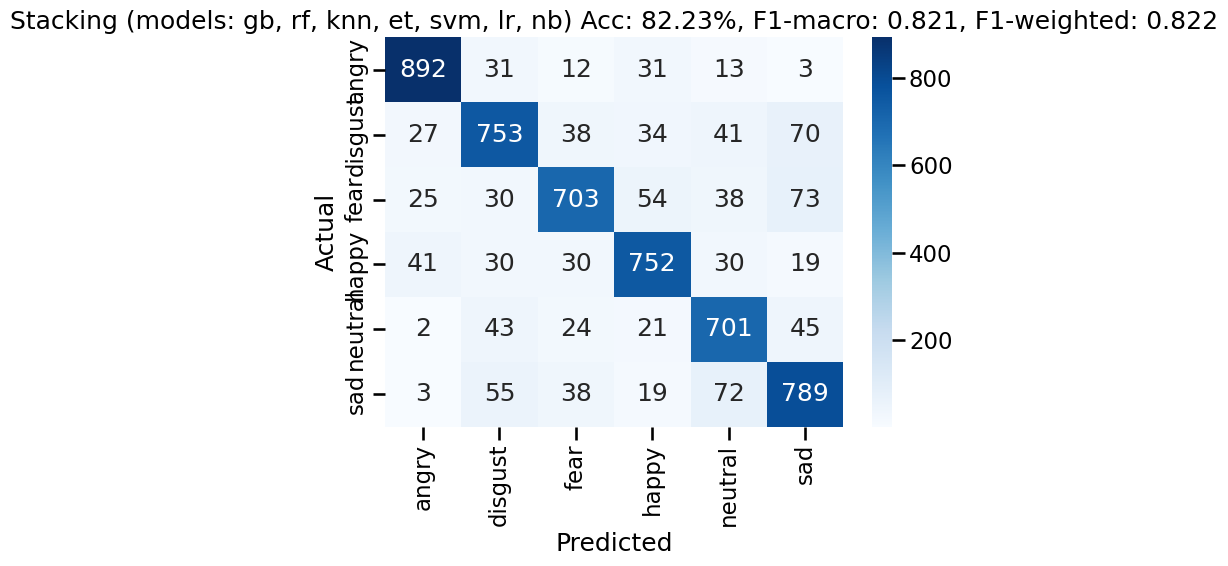

,num_models,models,accuracy,f1_macro,f1_weighted
5,7,"gb,rf,knn,et,svm,lr,nb",0.822286,0.821492,0.822086
4,6,"gb,rf,knn,et,svm,lr",0.820136,0.819435,0.819926
3,5,"gb,rf,knn,et,svm",0.813329,0.812634,0.813230
2,4,"gb,rf,knn,et",0.810641,0.809661,0.810424
1,3,"gb,rf,knn",0.805804,0.804836,0.805543
0,2,"gb,rf",0.789502,0.788380,0.789172


Best progressive stacking configuration: ['gb', 'rf', 'knn', 'et', 'svm', 'lr', 'nb'] with accuracy 0.8222859190254389


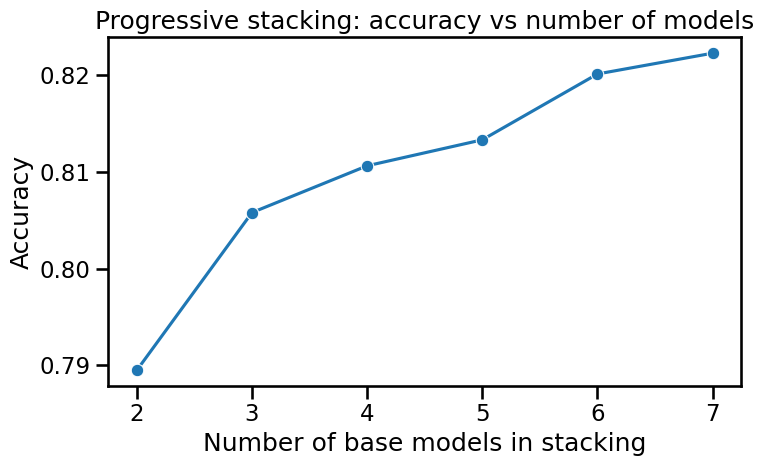


MODEL SAVED: best_model_optimised.pkl

Bundle contents:
  - model: best progressive StackingClassifier (7 base models)
  - confusion_matrix_ensemble: (6, 6)
  - confusion_matrix_components: (7, 6, 6)
  - class_labels: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']
  - accuracy: 0.8223


In [13]:
# Progressive stacking search starting from GradientBoosting (best base model)
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the base_models summary from the previous cell to determine ordering
# Anchor on GradientBoosting ('gb'), then add models from highest to lowest accuracy.
if 'confusion_df' not in globals():
    raise RuntimeError('Run the base-model confusion-matrix cell first to populate confusion_df.')

# Ensure we have a row for each of the tuned base models
required_models = ['gb', 'svm', 'rf', 'nb', 'et', 'knn', 'lr']
missing = [m for m in required_models if m not in confusion_df['model'].values]
if missing:
    raise RuntimeError(f'Missing models in confusion_df: {missing}. Re-run tuning / CM cells.')

anchor_name = 'gb'
other_models = confusion_df[confusion_df['model'] != anchor_name].sort_values('accuracy', ascending=False)['model'].tolist()
ordered_names = [anchor_name] + other_models
print('Progressive stacking order:', ordered_names)

sns.set_context('talk')
progressive_rows = []
best_acc = -1.0
best_f1_macro = -1.0
pipe_best_plain = None
best_models = None

for k in range(2, len(ordered_names) + 1):
    current_names = ordered_names[:k]
    print('Training stacking ensemble with models:', current_names)

    # Build estimators list for StackingClassifier from base_models dict
    estimators_subset = [(name, base_models[name]) for name in current_names]
    stacking_subset = StackingClassifier(
        estimators=estimators_subset,
        final_estimator=LogisticRegression(),
        cv=5
    )

    pipe_subset = Pipeline([
        ('scaler', StandardScaler()),
        ('stacking_clf', stacking_subset)
    ])

    pipe_subset.fit(X_train, y_train)
    y_pred_subset = pipe_subset.predict(X_test)
    acc_subset = accuracy_score(y_test, y_pred_subset)
    f1_macro = f1_score(y_test, y_pred_subset, average='macro')
    f1_weighted = f1_score(y_test, y_pred_subset, average='weighted')

    # Confusion matrix for this ensemble configuration
    labels = sorted(list(set(y_test)))
    cm_subset = confusion_matrix(y_test, y_pred_subset, labels=labels)
    cm_subset_df = pd.DataFrame(cm_subset, index=labels, columns=labels)

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm_subset_df, annot=True, fmt='d', cmap='Blues')
    title_line1 = 'Stacking (models: ' + ', '.join(current_names) + ')'
    title_line2 = f'Acc: {acc_subset*100:.2f}%, F1-macro: {f1_macro:.3f}, F1-weighted: {f1_weighted:.3f}'
    plt.title(title_line1 + ' ' + title_line2)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    progressive_rows.append({
        'num_models': k,
        'models': ','.join(current_names),
        'accuracy': acc_subset,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
    })

    # Track the best-performing stacking ensemble so we can reuse it later
    if acc_subset > best_acc or (acc_subset == best_acc and f1_macro > best_f1_macro):
        best_acc = acc_subset
        best_f1_macro = f1_macro
        pipe_best_plain = pipe_subset
        best_models = list(current_names)

if pipe_best_plain is None:
    raise RuntimeError('Progressive stacking did not produce any model.')

progressive_df = pd.DataFrame(progressive_rows)
display(progressive_df.sort_values('accuracy', ascending=False))
print('Best progressive stacking configuration:', best_models, 'with accuracy', best_acc)

# Summary plot: accuracy as models are added to the stacking ensemble
plt.figure(figsize=(8, 5))
progressive_df_sorted = progressive_df.sort_values('num_models')
sns.lineplot(data=progressive_df_sorted, x='num_models', y='accuracy', marker='o')
plt.xticks(progressive_df_sorted['num_models'])
plt.xlabel('Number of base models in stacking')
plt.ylabel('Accuracy')
plt.title('Progressive stacking: accuracy vs number of models')
plt.tight_layout()
plt.show()

# Persist the best progressive stacking model using a bundle similar to the Ultra Ensemble format
import pickle
best_model = pipe_best_plain
class_labels_stack = best_model.classes_
y_pred_best = best_model.predict(X_test)
cm_array_ensemble = confusion_matrix(y_test, y_pred_best, labels=class_labels_stack)

# Confusion matrices for the component base models that feed into the best stacking ensemble
cm_array_components = []
for name in best_models:
    base_model = base_models[name]
    y_comp = base_model.predict(X_test_scaled)
    cm_comp = confusion_matrix(y_test, y_comp, labels=class_labels_stack)
    cm_array_components.append(cm_comp)

bundle = {
    'model': best_model,
    'confusion_matrix_ensemble': cm_array_ensemble,
    'confusion_matrix_components': np.array(cm_array_components),
    'class_labels': class_labels_stack,
    'accuracy': best_acc,
}
pickle_filename = 'best_model_optimised.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(bundle, f)

print('\n' + '='*80)
print(f'MODEL SAVED: {pickle_filename}')
print('='*80)
print('\nBundle contents:')
print(f'  - model: best progressive StackingClassifier ({len(best_models)} base models)')
print(f'  - confusion_matrix_ensemble: {cm_array_ensemble.shape}')
print(f'  - confusion_matrix_components: {np.array(cm_array_components).shape}')
print(f'  - class_labels: {class_labels_stack}')
print(f'  - accuracy: {best_acc:.4f}')


# Best Ensemble with SelectKBest
After establishing the best ensemble model in the earlier cell, see if we can push performance further by tuning the Ensemble with SelectKBest

Best ensemble configuration (from previous cell): ['gb', 'rf', 'knn', 'et', 'svm', 'lr', 'nb']


/Users/yangqingwei/Library/CloudStorage/GoogleDrive-yangqingwei@gmail.com/My Drive/SUTD/Term 1/ML/ML Lab/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


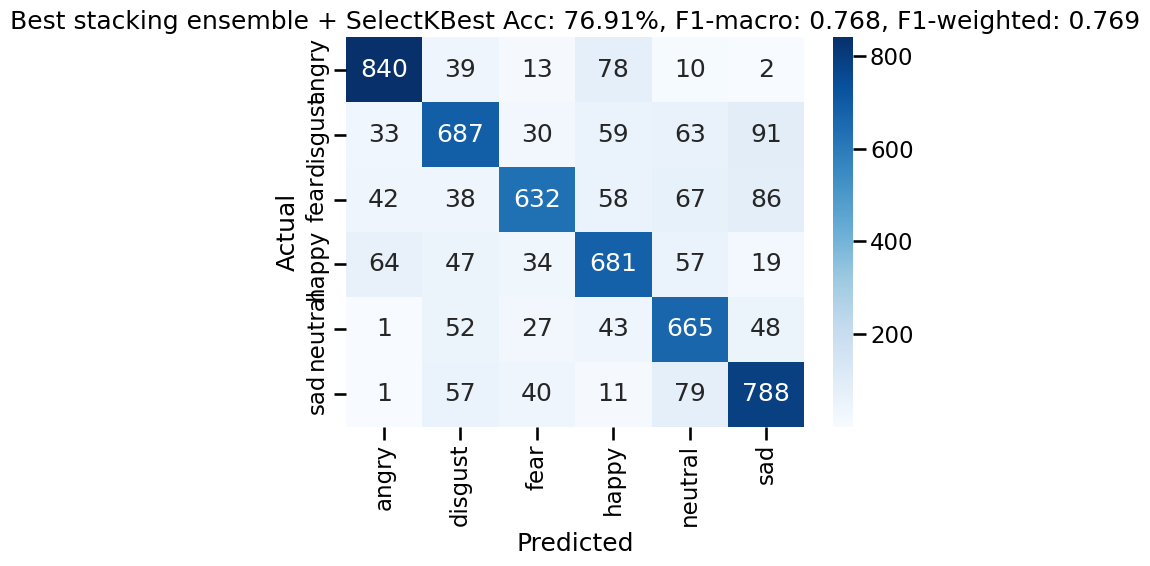

Best ensemble + SelectKBest results:
  Models       : ['gb', 'rf', 'knn', 'et', 'svm', 'lr', 'nb']
  Accuracy     : 0.7690791830884988
  F1 (macro)  : 0.7675780750084223
  F1 (weighted): 0.7687849155041603


In [14]:
# Best ensemble + SelectKBest: evaluate with confusion matrix and F1 scores
if 'progressive_df' not in globals():
    raise RuntimeError('Run the progressive stacking cell first to populate progressive_df.')

# Identify the best-performing ensemble configuration (by accuracy, then F1-macro)
best_row = progressive_df.sort_values(['accuracy', 'f1_macro'], ascending=False).iloc[0]
best_models = best_row['models'].split(',')
print('Best ensemble configuration (from previous cell):', best_models)

# Build a new pipeline: scaler -> SelectKBest -> stacking_clf with the best base models
estimators_best = [(name, base_models[name]) for name in best_models]
stacking_best = StackingClassifier(
    estimators=estimators_best,
    final_estimator=LogisticRegression(),
    cv=5
)

pipe_best_k = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(k=100, score_func=mutual_info_classif)),
    ('stacking_clf', stacking_best)
])

pipe_best_k.fit(X_train, y_train)
y_pred_best_k = pipe_best_k.predict(X_test)
acc_best_k = accuracy_score(y_test, y_pred_best_k)
f1_macro_best_k = f1_score(y_test, y_pred_best_k, average='macro')
f1_weighted_best_k = f1_score(y_test, y_pred_best_k, average='weighted')

# Confusion matrix for the SelectKBest-enhanced ensemble
labels = sorted(list(set(y_test)))
cm_best_k = confusion_matrix(y_test, y_pred_best_k, labels=labels)
cm_best_k_df = pd.DataFrame(cm_best_k, index=labels, columns=labels)

sns.set_context('talk')
plt.figure(figsize=(7, 6))
sns.heatmap(cm_best_k_df, annot=True, fmt='d', cmap='Blues')
title_line1 = 'Best stacking ensemble + SelectKBest'
title_line2 = 'Acc: ' + f'{acc_best_k*100:.2f}%' + ', F1-macro: ' + f'{f1_macro_best_k:.3f}' + ', F1-weighted: ' + f'{f1_weighted_best_k:.3f}'
plt.title(title_line1 + ' ' + title_line2)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('Best ensemble + SelectKBest results:')
print('  Models       :', best_models)
print('  Accuracy     :', acc_best_k)
print('  F1 (macro)  :', f1_macro_best_k)
print('  F1 (weighted):', f1_weighted_best_k)


# Attempt to create an Ultra Ensemble of best models
We'll see if we can push it further by combining Best Ensemble Model + Best Ensemble Model SelectKBest + Best Base Model

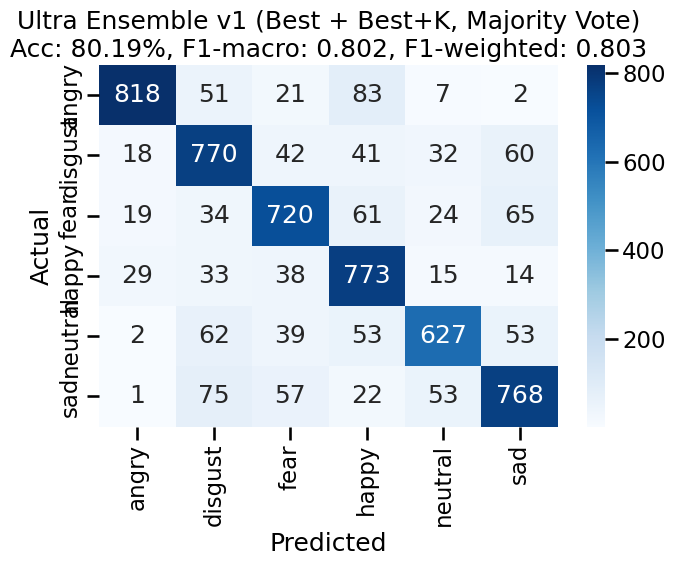

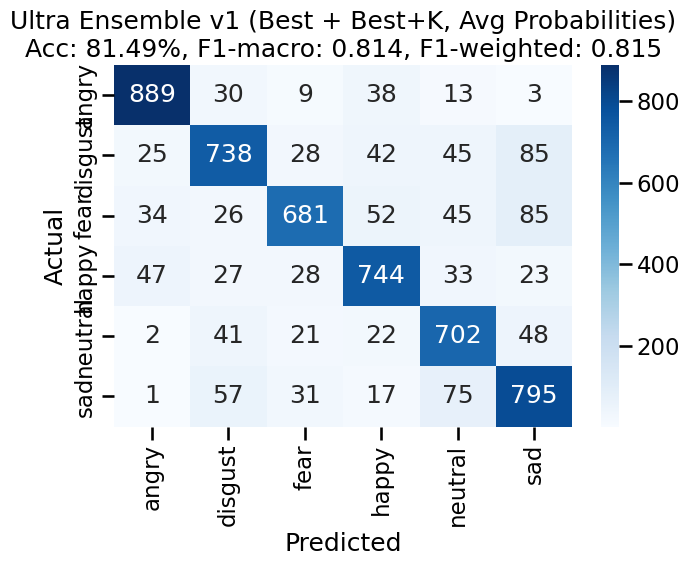

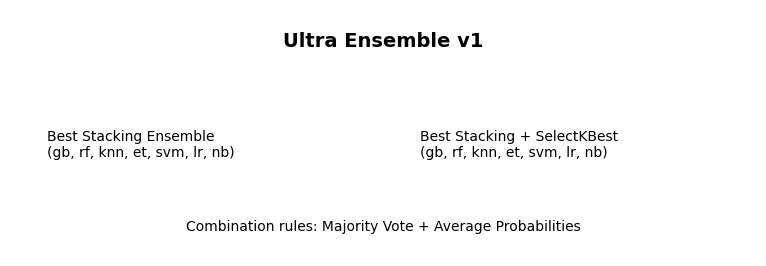

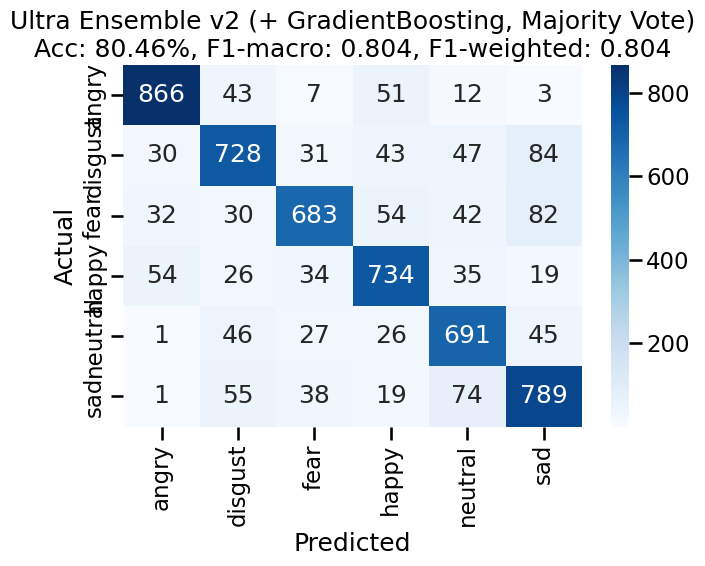

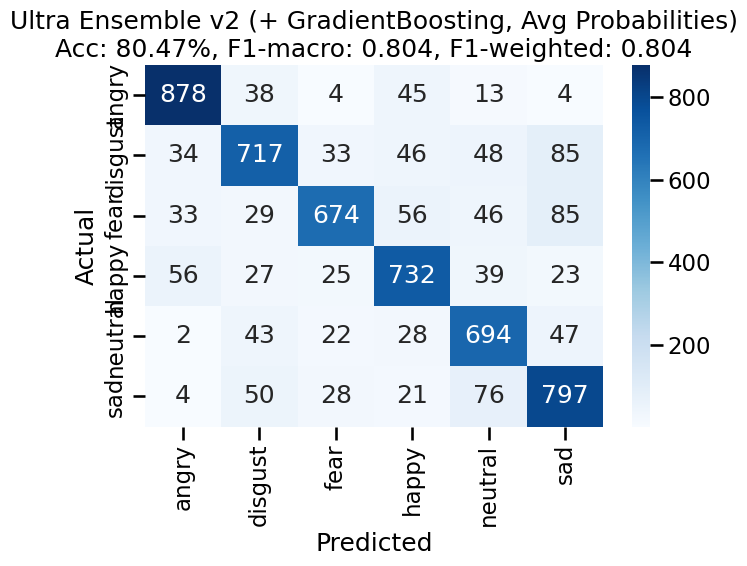

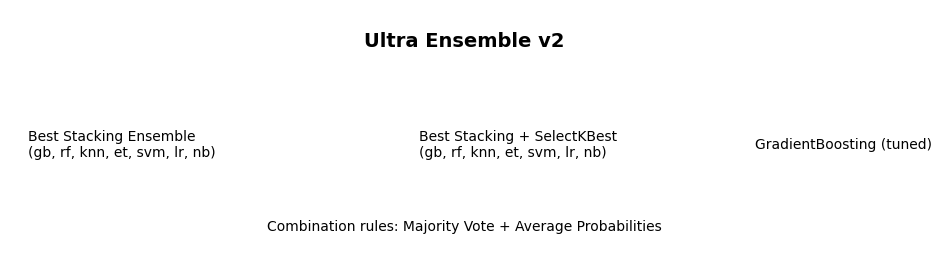

SAVING ULTRA ENSEMBLE MODEL
SAVING ULTRA ENSEMBLE MODELS V1 AND V2
MODEL SAVED: ultra_ensemble_model_v1.pkl
Bundle v1 contents:
  - model: UltraEnsembleModel (2 models combined)
  - confusion_matrix_ensemble: (6, 6)
  - confusion_matrix_components: (2, 6, 6)
  - class_labels: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']
  - accuracy: 0.8149
MODEL SAVED: ultra_ensemble_model_v2.pkl
Bundle v2 contents:
  - model: UltraEnsembleModel (3 models combined)
  - confusion_matrix_ensemble: (6, 6)
  - confusion_matrix_components: (3, 6, 6)
  - class_labels: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']
  - accuracy: 0.8047
USAGE EXAMPLE (Ultra Ensemble v2)

import pickle

with open('ultra_ensemble_model_v2.pkl', 'rb') as f:
    bundle = pickle.load(f)

# Extract components
model = bundle['model']
class_labels = bundle['class_labels']

# For new feature rows X_new with shape (n_samples, n_features):
proba = model.predict_proba(X_new)
max_proba = np.max(proba, axis=1)
y_pred = [class_lab

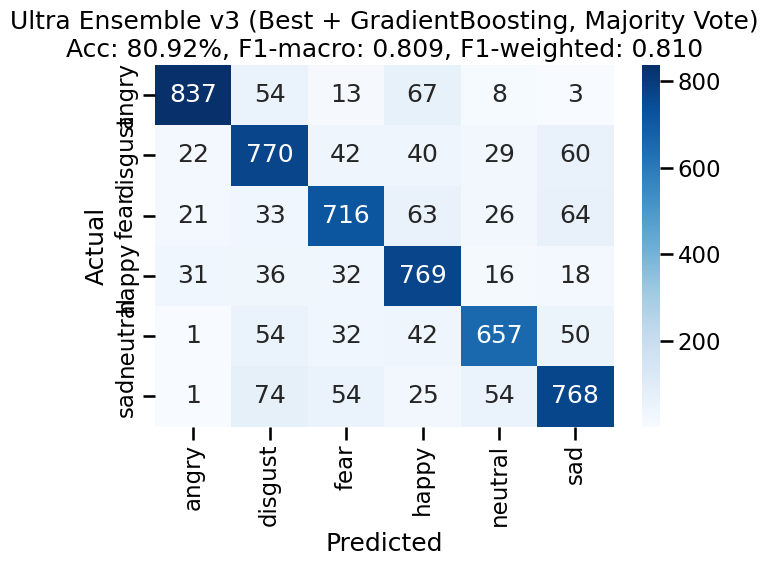

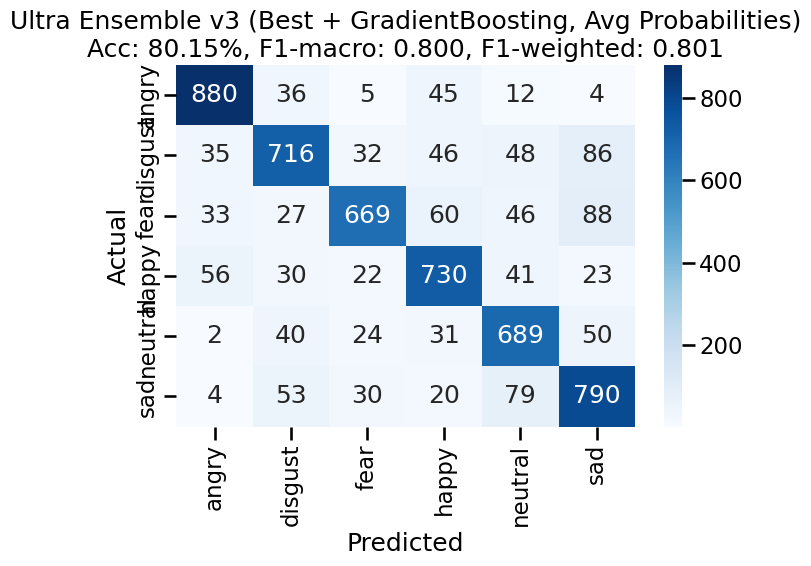

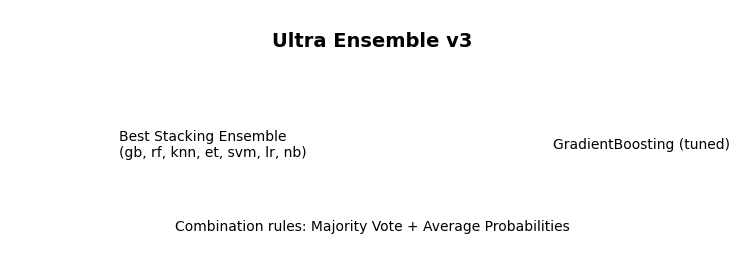

MODEL SAVED: ultra_ensemble_model_v3.pkl
Bundle v3 contents:
  - model: UltraEnsembleModel (2 models combined)
  - confusion_matrix_ensemble: (6, 6)
  - confusion_matrix_components: (2, 6, 6)
  - class_labels: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']
  - accuracy: 0.8015


In [16]:
# Ultra Ensemble models built from the best stacking ensembles (no retraining here)
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure required objects from previous cells are available
if 'pipe_best_plain' not in globals() or 'pipe_best_k' not in globals():
    raise RuntimeError('Run the progressive stacking and SelectKBest ensemble cells first.')

# Prefer a GradientBoosting pipeline if available; otherwise fall back to the tuned estimator
gb_model = None
if 'pipe_gb_clf' in globals():
    gb_model = pipe_gb_clf
elif 'second_best_gb' in globals():
    # second_best_gb was trained on X_train_scaled; wrap it so it always
    # applies the global scaler to raw inputs before predicting.
    if 'scaler' not in globals():
        raise RuntimeError('Global scaler not found; run the scaling cell before Ultra Ensemble.')

    class _GBScaledWrapper:
        def __init__(self, model, scaler_obj):
            self.model = model
            self.scaler = scaler_obj
            if hasattr(model, 'classes_'):
                self.classes_ = model.classes_

        def predict(self, X):
            X_scaled = self.scaler.transform(X)
            return self.model.predict(X_scaled)

        def predict_proba(self, X):
            X_scaled = self.scaler.transform(X)
            return self.model.predict_proba(X_scaled)

    gb_model = _GBScaledWrapper(second_best_gb, scaler)
else:
    raise RuntimeError('No GradientBoosting model found. Ensure it is trained before running this cell.')
# UltraEnsembleModel as specified (majority vote + average probabilities)
class UltraEnsembleModel:
    """Combines multiple models via majority voting"""

    def __init__(self, models_dict):
        self.models = models_dict

    def predict(self, X):
        all_preds = {}
        for name, model in self.models.items():
            all_preds[name] = model.predict(X)
        n_samples = len(next(iter(all_preds.values())))
        final_preds = []
        for i in range(n_samples):
            votes = [pred[i] for pred in all_preds.values()]
            final_preds.append(max(set(votes), key=votes.count))
        return np.array(final_preds)

    def predict_proba(self, X):
        all_probas = []
        for name, model in self.models.items():
            all_probas.append(model.predict_proba(X))
        return np.mean(all_probas, axis=0)

# Helper to evaluate and plot a confusion matrix
def evaluate_ensemble(y_true, y_pred, title_prefix, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')

    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    sns.set_context('talk')
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    title = f"{title_prefix}\nAcc: {acc*100:.2f}%, F1-macro: {f1_macro:.3f}, F1-weighted: {f1_weighted:.3f}"
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return {'accuracy': acc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted}

# 1) Ultra Ensemble v1: Best Ensemble + Best Ensemble + SelectKBest
models_v1 = {
    'best_stack': pipe_best_plain,
    'best_stack_k': pipe_best_k,
}
ultra_v1 = UltraEnsembleModel(models_v1)
model_keys_v1 = list(ultra_v1.models.keys())
class_labels = ultra_v1.models[model_keys_v1[0]].classes_

# Majority vote
y_ultra_v1_mv = ultra_v1.predict(X_test)
metrics_ultra_v1_mv = evaluate_ensemble(y_test, y_ultra_v1_mv,
    'Ultra Ensemble v1 (Best + Best+K, Majority Vote)', class_labels)

# Average probabilities
proba_v1 = ultra_v1.predict_proba(X_test)
y_ultra_v1_avg = np.array([class_labels[i] for i in np.argmax(proba_v1, axis=1)])
metrics_ultra_v1_avg = evaluate_ensemble(y_test, y_ultra_v1_avg,
    'Ultra Ensemble v1 (Best + Best+K, Avg Probabilities)', class_labels)

# Diagram for Ultra Ensemble v1
plt.figure(figsize=(8, 3))
plt.axis('off')
plt.text(0.5, 0.85, 'Ultra Ensemble v1', ha='center', fontsize=14, fontweight='bold')
plt.text(0.05, 0.45, 'Best Stacking Ensemble\n(' + ', '.join(best_models) + ')', fontsize=10, va='center')
plt.text(0.55, 0.45, 'Best Stacking + SelectKBest\n(' + ', '.join(best_models) + ')', fontsize=10, va='center')
plt.text(0.5, 0.1, 'Combination rules: Majority Vote + Average Probabilities',
         ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# 2) Ultra Ensemble v2: Add GradientBoosting (best base model)
models_v2 = {
    'best_stack': pipe_best_plain,
    'best_stack_k': pipe_best_k,
    'gb': gb_model,
}
ultra_v2 = UltraEnsembleModel(models_v2)
model_keys_v2 = list(ultra_v2.models.keys())
# class_labels remains the same ordering as before

# Majority vote
y_ultra_v2_mv = ultra_v2.predict(X_test)
metrics_ultra_v2_mv = evaluate_ensemble(y_test, y_ultra_v2_mv,
    'Ultra Ensemble v2 (+ GradientBoosting, Majority Vote)', class_labels)

# Average probabilities
proba_v2 = ultra_v2.predict_proba(X_test)
y_ultra_v2_avg = np.array([class_labels[i] for i in np.argmax(proba_v2, axis=1)])
metrics_ultra_v2_avg = evaluate_ensemble(y_test, y_ultra_v2_avg,
    'Ultra Ensemble v2 (+ GradientBoosting, Avg Probabilities)', class_labels)

# Diagram for Ultra Ensemble v2
plt.figure(figsize=(10, 3))
plt.axis('off')
plt.text(0.5, 0.85, 'Ultra Ensemble v2', ha='center', fontsize=14, fontweight='bold')
plt.text(0.02, 0.45, 'Best Stacking Ensemble\n(' + ', '.join(best_models) + ')', fontsize=10, va='center')
plt.text(0.45, 0.45, 'Best Stacking + SelectKBest\n(' + ', '.join(best_models) + ')', fontsize=10, va='center')
plt.text(0.82, 0.45, 'GradientBoosting (tuned)', fontsize=10, va='center')
plt.text(0.5, 0.1, 'Combination rules: Majority Vote + Average Probabilities',
         ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print("="*80)
print("SAVING ULTRA ENSEMBLE MODEL")
print("="*80)

import pickle
# Save Ultra Ensemble v1 and v2 bundles
print('='*80)
print('SAVING ULTRA ENSEMBLE MODELS V1 AND V2')
print('='*80)

# Confusion matrices and bundles for Ultra Ensemble v1 (using Avg Probabilities)
cm_array_ensemble_v1 = confusion_matrix(y_test, y_ultra_v1_avg, labels=class_labels)
cm_array_components_v1 = []
for name, model in models_v1.items():
    y_comp = model.predict(X_test)
    cm_array_components_v1.append(confusion_matrix(y_test, y_comp, labels=class_labels))
best_accuracy_final_v1 = metrics_ultra_v1_avg['accuracy']

bundle_v1 = {
    'model': ultra_v1,
    'confusion_matrix_ensemble': cm_array_ensemble_v1,
    'confusion_matrix_components': np.array(cm_array_components_v1),
    'class_labels': class_labels,
    'accuracy': best_accuracy_final_v1,
}
pickle_filename_v1 = 'ultra_ensemble_model_v1.pkl'
with open(pickle_filename_v1, 'wb') as f:
    pickle.dump(bundle_v1, f)

print('='*80)
print(f'MODEL SAVED: {pickle_filename_v1}')
print('='*80)
print('Bundle v1 contents:')
print(f"  - model: UltraEnsembleModel ({len(models_v1)} models combined)")
print(f"  - confusion_matrix_ensemble: {cm_array_ensemble_v1.shape}")
print(f"  - confusion_matrix_components: {np.array(cm_array_components_v1).shape}")
print(f"  - class_labels: {class_labels}")
print(f"  - accuracy: {best_accuracy_final_v1:.4f}")

# Confusion matrices and bundles for Ultra Ensemble v2 (using Avg Probabilities)
cm_array_ensemble_v2 = confusion_matrix(y_test, y_ultra_v2_avg, labels=class_labels)
cm_array_components_v2 = []
for name, model in models_v2.items():
    y_comp = model.predict(X_test)
    cm_array_components_v2.append(confusion_matrix(y_test, y_comp, labels=class_labels))
best_accuracy_final_v2 = metrics_ultra_v2_avg['accuracy']

bundle_v2 = {
    'model': ultra_v2,
    'confusion_matrix_ensemble': cm_array_ensemble_v2,
    'confusion_matrix_components': np.array(cm_array_components_v2),
    'class_labels': class_labels,
    'accuracy': best_accuracy_final_v2,
}
pickle_filename_v2 = 'ultra_ensemble_model_v2.pkl'
with open(pickle_filename_v2, 'wb') as f:
    pickle.dump(bundle_v2, f)

print('='*80)
print(f'MODEL SAVED: {pickle_filename_v2}')
print('='*80)
print('Bundle v2 contents:')
print(f"  - model: UltraEnsembleModel ({len(models_v2)} models combined)")
print(f"  - confusion_matrix_ensemble: {cm_array_ensemble_v2.shape}")
print(f"  - confusion_matrix_components: {np.array(cm_array_components_v2).shape}")
print(f"  - class_labels: {class_labels}")
print(f"  - accuracy: {best_accuracy_final_v2:.4f}")

print('='*80)
print('USAGE EXAMPLE (Ultra Ensemble v2)')
print('='*80)
print("""
import pickle

with open('ultra_ensemble_model_v2.pkl', 'rb') as f:
    bundle = pickle.load(f)

# Extract components
model = bundle['model']
class_labels = bundle['class_labels']

# For new feature rows X_new with shape (n_samples, n_features):
proba = model.predict_proba(X_new)
max_proba = np.max(proba, axis=1)
y_pred = [class_labels[i] for i in np.argmax(proba, axis=1)]
""")

# 3) Ultra Ensemble v3: Best Ensemble + GradientBoosting (no SelectKBest)
models_v3 = {
    'best_stack': pipe_best_plain,
    'gb': gb_model,
}
ultra_v3 = UltraEnsembleModel(models_v3)

# Majority vote evaluation
y_ultra_v3_mv = ultra_v3.predict(X_test)
metrics_ultra_v3_mv = evaluate_ensemble(
    y_test, y_ultra_v3_mv,
    'Ultra Ensemble v3 (Best + GradientBoosting, Majority Vote)',
    class_labels,
)

# Average probabilities evaluation
proba_v3 = ultra_v3.predict_proba(X_test)
y_ultra_v3_avg = np.array([class_labels[i] for i in np.argmax(proba_v3, axis=1)])
metrics_ultra_v3_avg = evaluate_ensemble(
    y_test, y_ultra_v3_avg,
    'Ultra Ensemble v3 (Best + GradientBoosting, Avg Probabilities)',
    class_labels,
)

# Diagram of Ultra Ensemble v3 composition
plt.figure(figsize=(8, 3))
plt.axis('off')
plt.text(0.5, 0.85, 'Ultra Ensemble v3', ha='center', fontsize=14, fontweight='bold')
plt.text(0.15, 0.45, 'Best Stacking Ensemble\n(' + ', '.join(best_models) + ')',
         fontsize=10, va='center')
plt.text(0.75, 0.45, 'GradientBoosting (tuned)', fontsize=10, va='center')
plt.text(0.5, 0.1, 'Combination rules: Majority Vote + Average Probabilities',
         ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# Save Ultra Ensemble v3 bundle (using Avg Probabilities metrics)
cm_array_ensemble_v3 = confusion_matrix(y_test, y_ultra_v3_avg, labels=class_labels)
cm_array_components_v3 = []
for name, model in models_v3.items():
    y_comp = model.predict(X_test)
    cm_array_components_v3.append(confusion_matrix(y_test, y_comp, labels=class_labels))
best_accuracy_final_v3 = metrics_ultra_v3_avg['accuracy']

bundle_v3 = {
    'model': ultra_v3,
    'confusion_matrix_ensemble': cm_array_ensemble_v3,
    'confusion_matrix_components': np.array(cm_array_components_v3),
    'class_labels': class_labels,
    'accuracy': best_accuracy_final_v3,
}
pickle_filename_v3 = 'ultra_ensemble_model_v3.pkl'
with open(pickle_filename_v3, 'wb') as f:
    pickle.dump(bundle_v3, f)

print('='*80)
print(f'MODEL SAVED: {pickle_filename_v3}')
print('='*80)
print('Bundle v3 contents:')
print(f"  - model: UltraEnsembleModel ({len(models_v3)} models combined)")
print(f"  - confusion_matrix_ensemble: {cm_array_ensemble_v3.shape}")
print(f"  - confusion_matrix_components: {np.array(cm_array_components_v3).shape}")
print(f"  - class_labels: {class_labels}")
print(f"  - accuracy: {best_accuracy_final_v3:.4f}")
